# `Maranatha.jl` :: Practical Reporting Workflow

This notebook demonstrates a realistic end-to-end workflow for
analyzing a quadrature study and producing reproducible research
artifacts using `Maranatha.jl`.

Unlike the earlier pedagogical examples, this notebook combines
multiple stages of a typical numerical experiment:

- running a concrete quadrature setup,
- inspecting raw datapoints,
- generating datapoints-only reports,
- performing continuum extrapolation,
- visualizing fitted results,
- producing publication-ready summaries and internal notes.

This workflow illustrates how a single experiment can be turned into
a complete documentation package suitable for archival, collaboration,
or inclusion in research reports.

The overall workflow is:

1. Define and run a concrete quadrature experiment
2. Inspect the raw convergence datapoints
3. Generate datapoints-only summaries and internal notes
4. Perform least-chi-square fitting
5. Visualize the fitted convergence behavior
6. Produce fit-aware summaries and final internal notes


## Initialize Julia environment

First we configure the Julia runtime and load the
**`Maranatha.jl`** package.

In [1]:
ENV["JULIA_NUM_THREADS"] = get(ENV, "JULIANUM_THREADS", "4")

using Maranatha

## Practical reporting workflow

This notebook demonstrates a more realistic end-to-end workflow
using `Maranatha.jl`.

Unlike the earlier pedagogical notebooks, this example is closer to
actual research usage. It combines

- a registered custom integrand,
- a concrete quadrature setup,
- raw datapoint inspection,
- datapoints-only reporting,
- least-chi-square fitting,
- fit-aware summaries and internal-note generation.

The goal is to show how a single numerical experiment can be turned
into a complete set of reusable research artifacts.

## Register the integrand and define the numerical setup

We begin by loading and registering a concrete integrand used in
a more realistic workflow.

This notebook uses an $F_{0000} - \gamma_E + 1$-related example together with a
specific quadrature rule, boundary condition, error-estimation backend,
and resolution range.

The setup is intentionally more detailed than in the introductory
notebooks so that the full reporting pipeline can be demonstrated
under conditions closer to actual usage.

In [2]:
include("../test/complicated/experiments/integrand_F0000GammaEminus1.jl")

register_F0000_integrand!()

ff_tilde(x)  = gtilde_F0000(x; p=4)
ff(x)  = g_F0000_raw(x)

bounds = (0.0, 1.0)
use_threads = false
dim = 1
rule = :gauss_p2
boundary = :LU_EXEX
ns = [2, 3, 4, 5, 6, 7, 8, 9]
ns .+= 20
err_method = :fastdifferentiation # :forwarddiff , :taylorseries , :enzyme , :fastdifferentiation
nerr_terms = 3
ff_shift = 0
fit_terms = 4
result_string = "F0000_FastDiff"
save_path = joinpath("../samples", "jld2")
write_summary = true
save_file = true

true

## Run the quadrature study

Now we generate the raw convergence dataset.

This step produces the core numerical output needed for the later
stages of the workflow:

- raw step sizes,
- quadrature estimates,
- pointwise error information,
- metadata describing the run configuration.

These results will first be inspected directly, and only afterward
used for fitting and final reporting.

In [3]:
run_result = run_Maranatha(
    ff, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method,
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms,
    ff_shift=ff_shift, 
    use_threads=use_threads,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary  
)

(a = 0.0, b = 1.0, h = [0.045454545454545456, 0.043478260869565216, 0.041666666666666664, 0.04, 0.038461538461538464, 0.037037037037037035, 0.03571428571428571, 0.034482758620689655], avg = [4.7920260896769715, 4.792027961167576, 4.792027219041575, 4.7920250744181505, 4.792022338471625, 4.79201952202756, 4.792016920600444, 4.792014682113776], err = NamedTuple[(ks = [4, 5, 6], coeffs = [0.00509259259342798, 6.063298011819521e-13, 0.10253894767956809], derivatives = [2.610212148672811e6, 9.073670626820049e7, 3.5027936891698966e9], terms = [0.002579296902768163, 4.852391572981328e-13, 0.14399408382976733], total = 0.14657338073302073, center = 0.5, h = 0.045454545454545456), (ks = [4, 5, 6], coeffs = [0.005324074075057675, 1.2126596023639043e-13, 0.11718244782597241], derivatives = [2.610212148672811e6, 9.073670626820049e7, 3.5027936891698966e9], terms = [0.0021591395659226837, 7.432842055145586e-14, 0.12055417968282613], total = 0.12271331924882314, center = 0.5, h = 0.043478260869565216

## Build a result-file style name

For the reporting utilities, it is useful to keep a stable filename-style
identifier associated with the generated dataset.

Here we construct a result-like path string that reflects the chosen
experiment name, rule, boundary condition, and list of subdivision counts.

This makes the saved plots and generated report artifacts easier to
track and organize.

In [4]:
Nstr = join(sort(ns), "_")
run_result_file = joinpath(
    save_path,
    "result_$(result_string)_$(rule)_$(boundary)_N_$(Nstr).jld2"
)

"../samples/jld2/result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29.jld2"

## Inspect the raw datapoints first

Before fitting, it is often useful to inspect the raw quadrature
datapoints directly.

This allows us to check

- how the estimates behave across resolutions,
- whether the chosen horizontal scaling is sensible,
- whether the retained range appears smooth enough for later fitting,
- and whether there are suspicious outliers or irregular points.

In this example we use a logarithmic x-axis together with
the transformed coordinate ``h^4``.

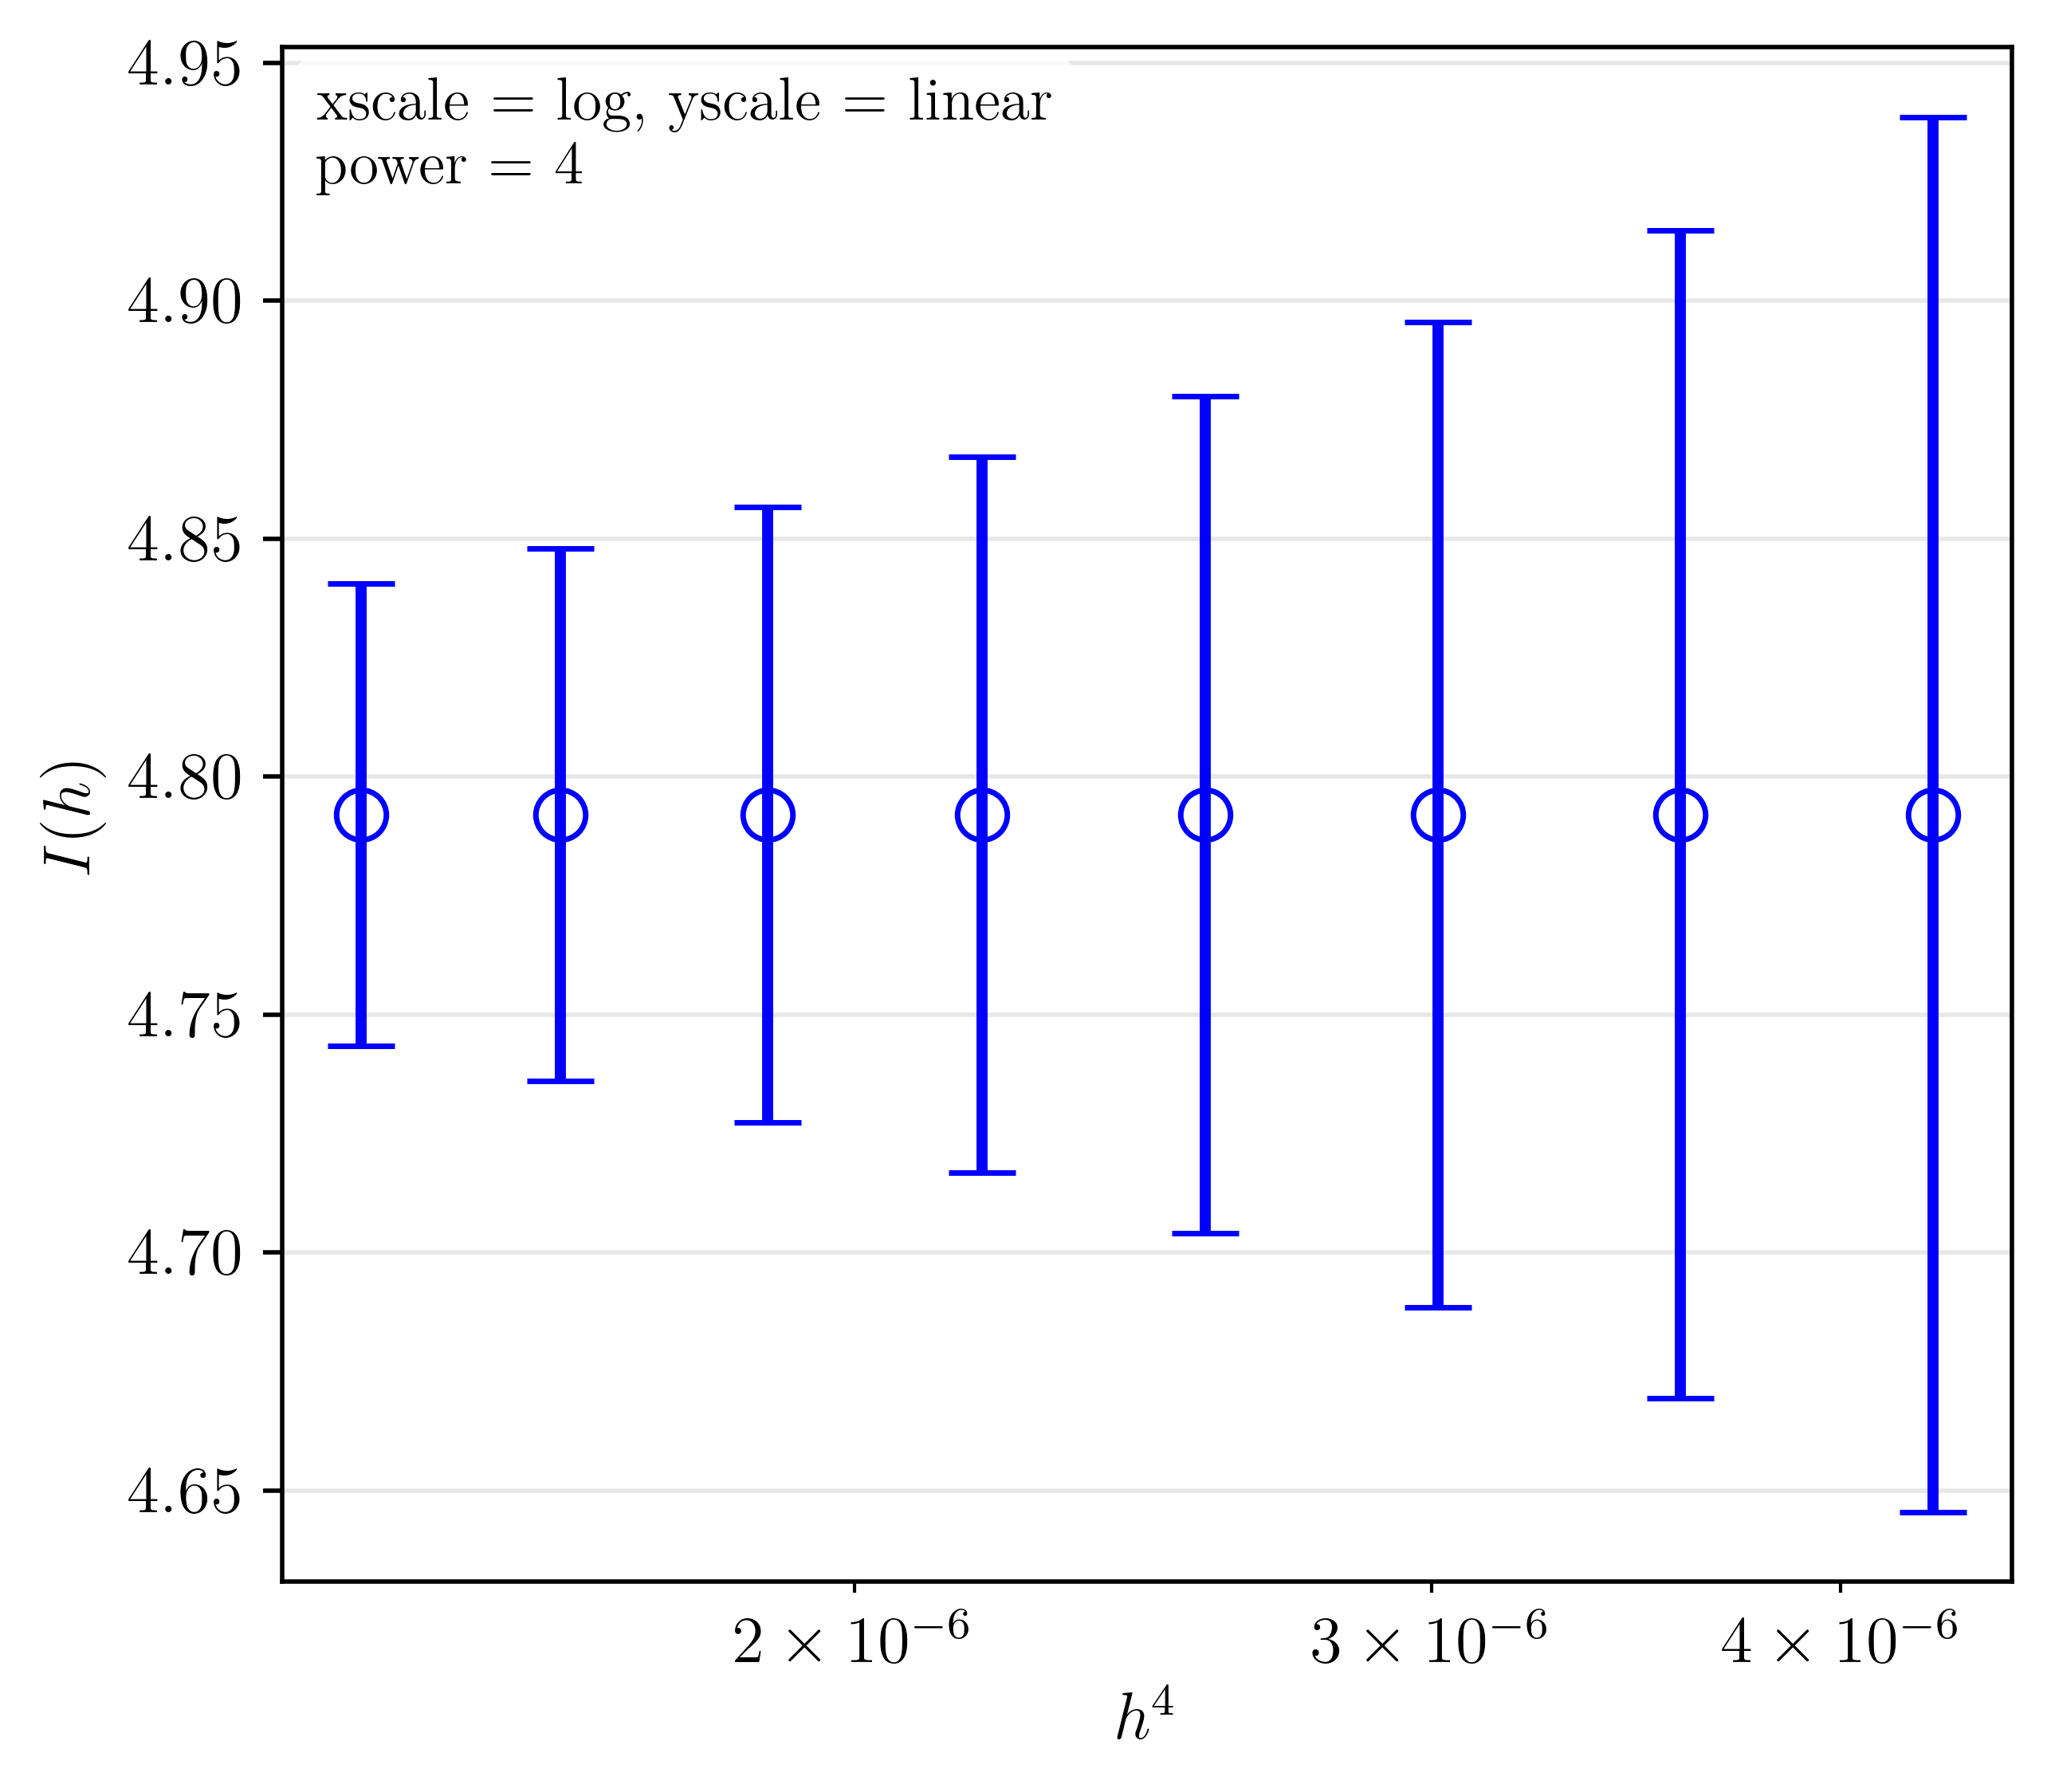

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_gauss_p2_LU_EXEX_datapoints_hpow_4_log_linear-crop.pdf'.


In [5]:
h_power = 4
xscale = :log
yscale = :linear

plot_datapoints_result(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    rule = run_result.rule,
    boundary = run_result.boundary,
    figs_dir = save_path,
    save_file = true
)

## Export a datapoints-only summary

Visual inspection is useful, but it is also valuable to save the
raw datapoints in a structured report format.

The datapoints-only summary records

- the step sizes,
- the transformed horizontal coordinate,
- the quadrature estimates,
- the uncertainty values,
- and the plotting convention used for inspection.

This provides a lightweight but reproducible record of the pre-fit stage.

In [6]:
write_convergence_summary_datapoints(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    rule = run_result.rule,
    boundary = run_result.boundary,
    format = :md,
    out_dir = save_path,
    save_file = true,
)

"# Convergence datapoints summary: ../samples/jld2/result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29.jld2\n\n## Run configuration\n\n| Interval | Rule (Boundary) | Plot setup |\n|:--|:--|:--|\n| `[0.0, 1.0]` | `gauss_p2 (LU_EXEX)` | `h^4`, `log/linear` |\n\n## Quadrature " ⋯ 197 bytes ⋯ "7e-02` | `3.014082e-06` | 4.79(10) |\n| `4.000000e-02` | `2.560000e-06` | 4.792(88) |\n| `3.846154e-02` | `2.188299e-06` | 4.792(75) |\n| `3.703704e-02` | `1.881676e-06` | 4.792(65) |\n| `3.571429e-02` | `1.626926e-06` | 4.792(56) |\n| `3.448276e-02` | `1.413865e-06` | 4.792(49) |\n"

## Generate a datapoints-only internal note

Next we construct a self-contained internal note for the raw dataset
before any fit is applied.

This note collects the datapoints summary together with the saved
datapoints plot inside a buildable LaTeX project.

Such an artifact is useful when you want to archive or share the
pre-fit behavior of a numerical experiment independently of the
final extrapolation step.

In [7]:
note_info = write_convergence_internal_note_datapoints(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    rule = run_result.rule,
    boundary = run_result.boundary,
    out_dir = save_path,
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
)

pdflatex inote_summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode

(./inote_summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_
29_hpow_4_log_linear.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/usr/local/texl

(note_dir = "../samples/jld2/inote_summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear", figs_dir = "../samples/jld2/inote_summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear/figs", summary_tex_path = "../samples/jld2/inote_summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear/summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear_table.tex", fig_tex_path = "../samples/jld2/inote_summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear/summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear_figs.tex", master_tex_path = "../samples/jld2/inote_summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear/inote_summary_result_F0000_FastDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear.tex", makefile_path = "../samples/jld2/inote

### Tag outputs for Lesson 6

To avoid overwriting files generated in previous lessons,
we append a lesson-specific suffix to the result name.

This modified identifier will be used by downstream functions
(such as plotting or report generation) when constructing
output filenames.

In [8]:
result_string = "lesson6_" * result_string

"lesson6_F0000_FastDiff"

## Perform the continuum extrapolation

After documenting the raw datapoints, we now carry out the
least-chi-square fit.

This produces the fitted model parameters together with the
extrapolated $h \to 0$ estimate and its uncertainty.

At this stage the workflow transitions from raw-data inspection
to the actual continuum-analysis step.

In [9]:
fit_nterms = 2
fit_nerr_terms = 3

fit_result = least_chi_square_fit(
    run_result; 
    nterms=fit_nterms, 
    ff_shift=0, 
    nerr_terms=fit_nerr_terms
)

print_fit_result(fit_result)

[2026-03-14 19:07:13.648] residual ks (backend) = [4, 5], fit powers (h^p), ff_shift=0 = [4]
[2026-03-14 19:07:14.689]            λ_0 = 4.792(78)
[2026-03-14 19:07:14.769]            λ_1 = 0.0e+04(37) *
[2026-03-14 19:07:14.769] 
[2026-03-14 19:07:14.769] Chi^2 / d.o.f. = 4.608421332147e-09 / 6 = 7.680702220246e-10
[2026-03-14 19:07:14.770] Result (h→0)   = 4.792(78)
[2026-03-14 19:07:14.770] 


## Visualize the fitted convergence result

With the fit result in hand, we can now generate the standard
fit-aware convergence plots.

These figures combine

- the fitted model curve,
- the uncertainty band,
- the original datapoints with error bars,
- the extrapolated point,
- and the relative convergence-error view.

This is the main visualization layer for interpreting the fit.

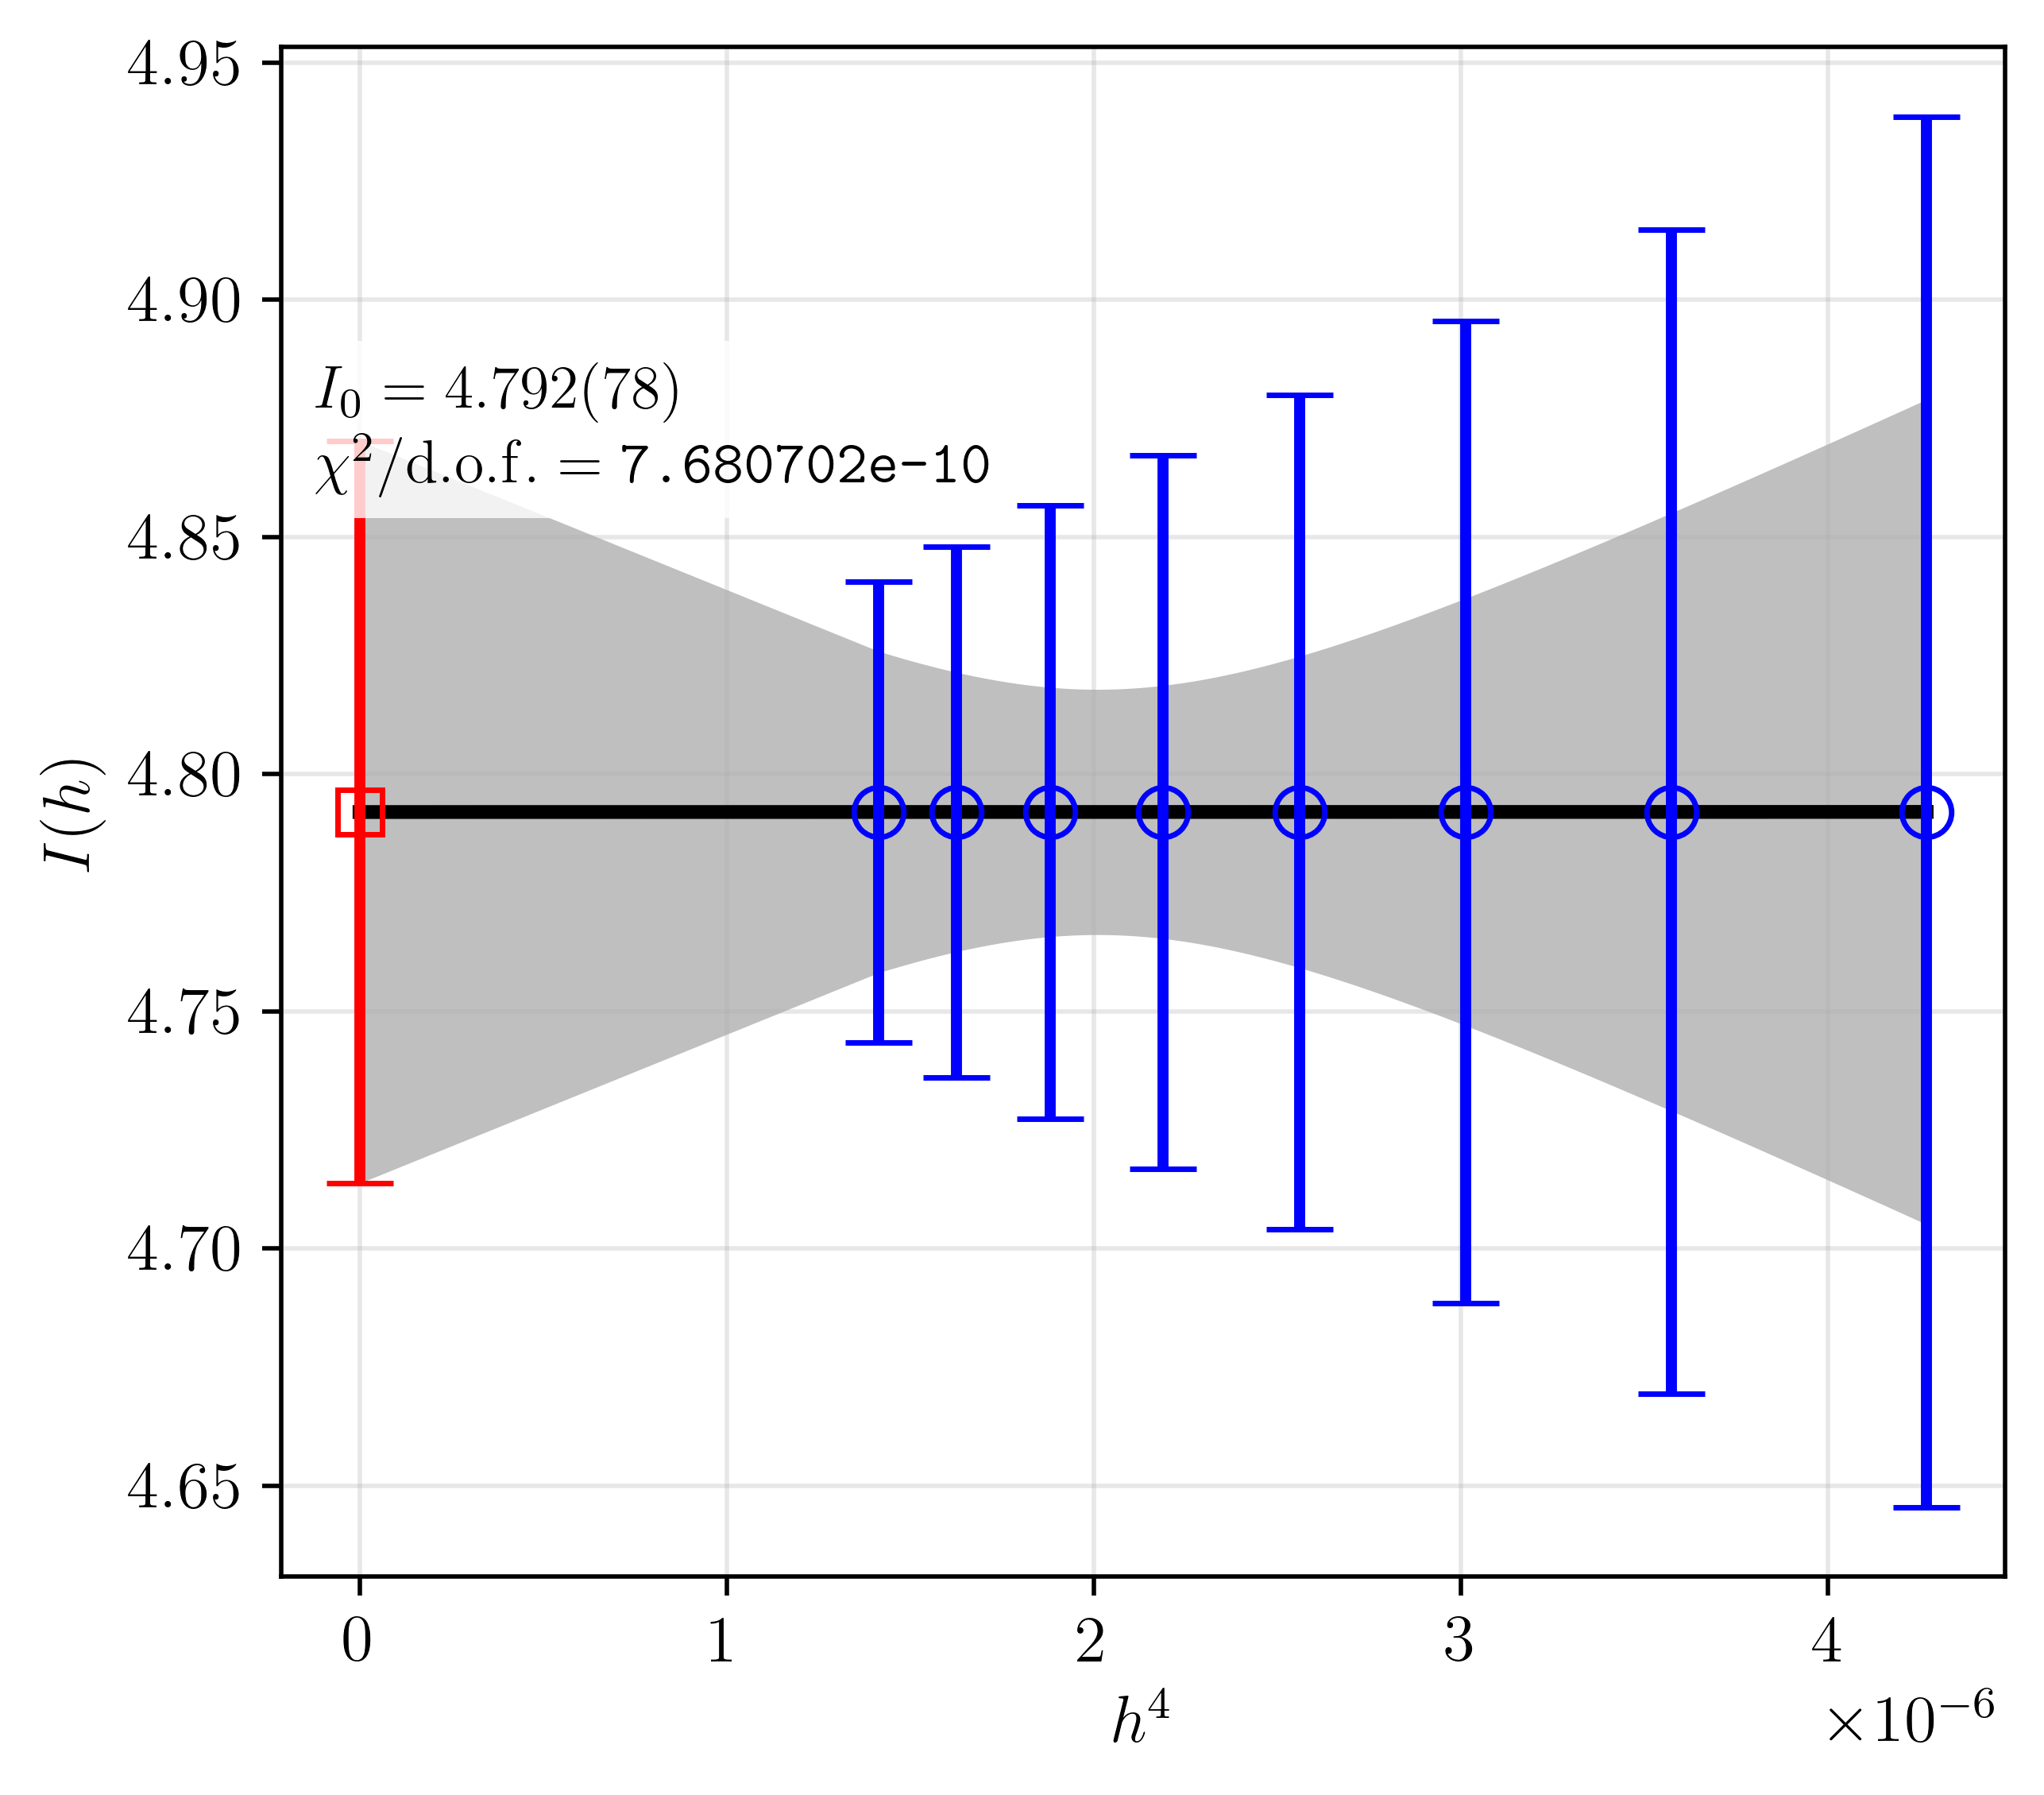

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_reldiff-crop.pdf'.


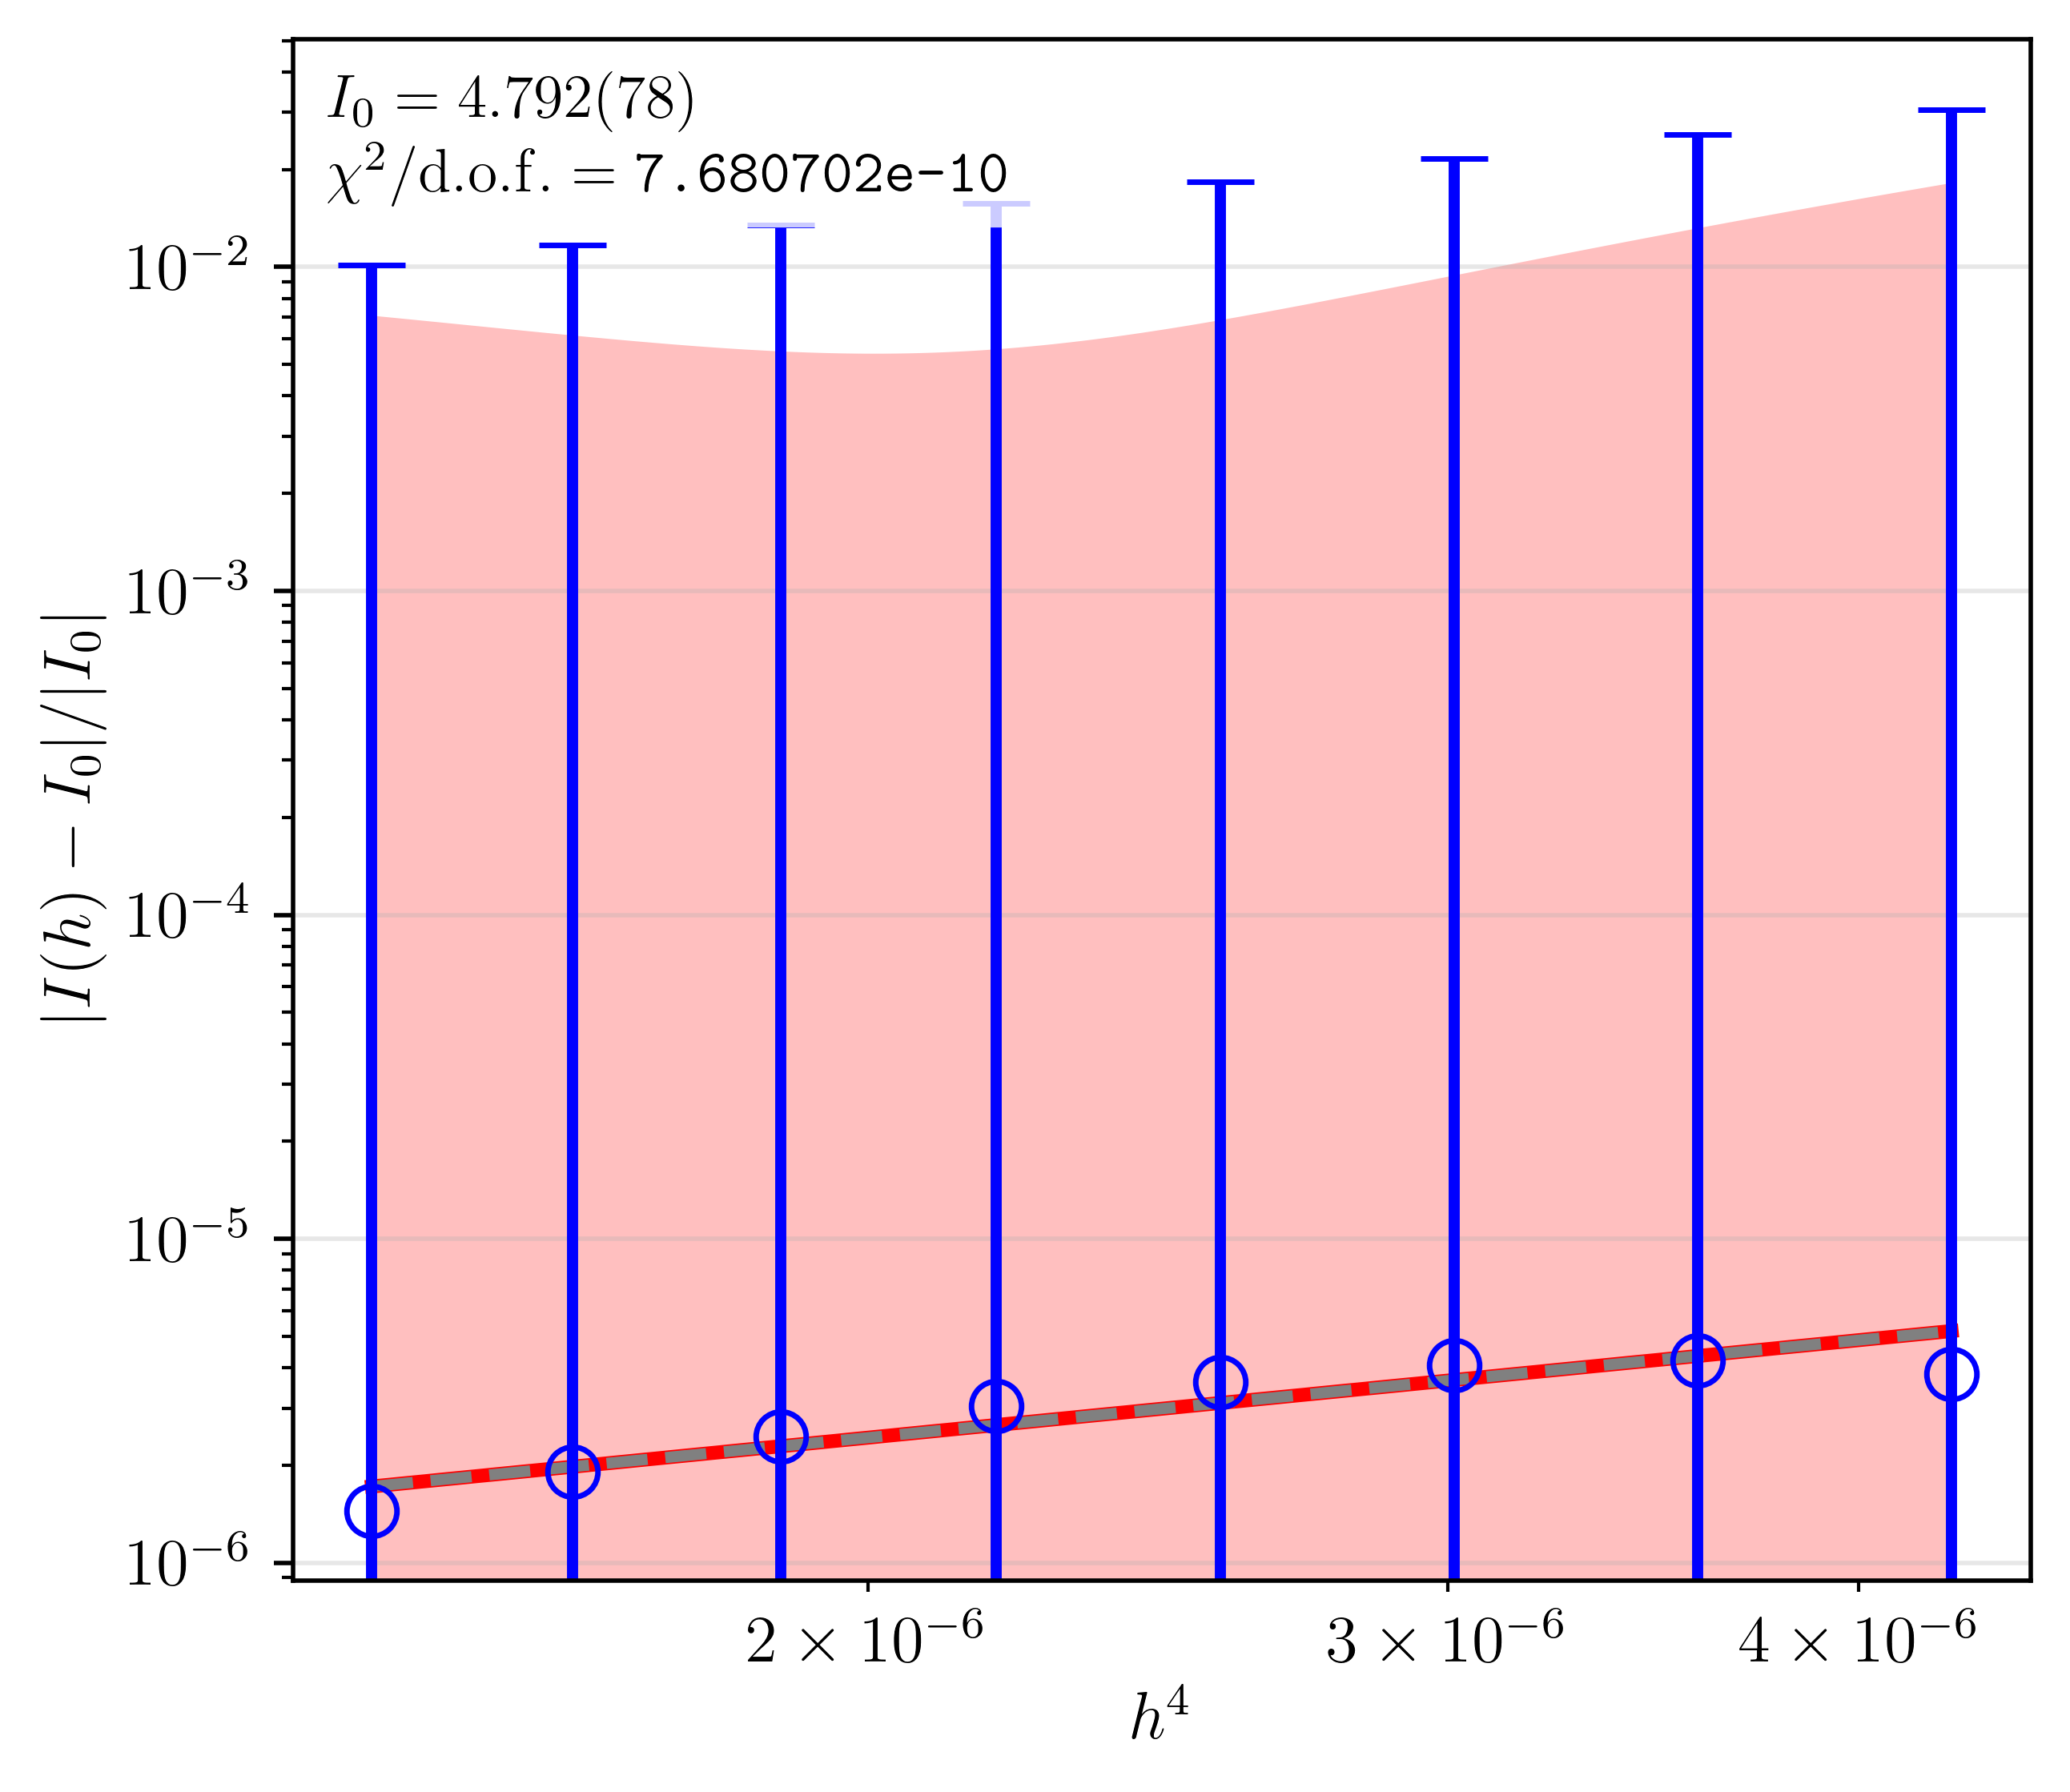

In [10]:
plot_convergence_result(
    run_result, 
    fit_result;
    name=result_string,
    figs_dir=save_path,
    save_file=true
)

## Export the fit-aware convergence summary

We now generate the full convergence summary including the fit result.

Unlike the earlier datapoints-only report, this summary also records

- fitted parameters,
- the extrapolated value,
- uncertainty information from the fit,
- and goodness-of-fit diagnostics.

This is the standard summary artifact for the final analysis stage.

In [ ]:
write_convergence_summary(
    run_result,
    fit_result;
    name = result_string,
    format = :md,
    out_dir = save_path,
    save_file = true,
    nterms=fit_nterms, 
    nerr_terms=fit_nerr_terms,
)

"# Convergence summary: lesson6_F0000_FastDiff\n\n## Run configuration\n\n| Interval | Rule (Boundary) | Number of error terms |\n|:--|:--|:--|\n| `[0.0, 1.0]` | `gauss_p2 (LU_EXEX)` | `3` |\n\n## Quadrature estimates and uncertainties for different step sizes\n\n| \$h\$ | \$h^4\$ | \$I(h)\$ |\n|:-" ⋯ 420 bytes ⋯ "e+00` | **4.792(78)** |\n\n## Least-chi-square fit results for extrapolation to \$h \\to 0\$\n\n```math\nf(h) = \\lambda_0 + \\lambda_1 h^{4}\n```\n\n| parameter | fit result |\n|:--|:--|\n| \$\\lambda_0\$ | **4.792(78)** |\n| \$\\lambda_1\$ | 0.0e+04(37) * |\n| \$\\chi^2 / \\text{d.o.f.}\$ | `7.680702e-10` |\n"

## Build the final internal note

Finally, we generate a complete internal note for the fitted analysis.

This note combines

- the fit-aware summary tables,
- the saved convergence figures,
- a REVTeX-based master document,
- and a reproducible build structure.

At this point the workflow has produced both

- pre-fit reporting artifacts, and
- final fit-based reporting artifacts

from a single numerical experiment.

In [12]:
note_info = write_convergence_internal_note(
    run_result,
    fit_result;
    name = result_string,
    rule = run_result.rule,
    boundary = run_result.boundary,
    out_dir = save_path,
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
    nterms=fit_nterms, 
    nerr_terms=fit_nerr_terms,
    # author = "Benjamin J. Choi",
    # affiliation = "Center for Computational Sciences, University of Tsukuba, 1-1-1 Tennodai, Tsukuba, Ibaraki 305-8577, Japan",
    # abstract_text = "This note summarizes the convergence study and fitted extrapolation result."
)

pdflatex inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/aps12pt4-2.rtx)
(/usr/local/tex

(note_dir = "../samples/jld2/inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3", figs_dir = "../samples/jld2/inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3/figs", summary_tex_path = "../samples/jld2/inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3/summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3_table.tex", fig_tex_path = "../samples/jld2/inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3/summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3_figs.tex", master_tex_path = "../samples/jld2/inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3/inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3.tex", makefile_path = "../samples/jld2/inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3/Makefile", moved_plots = ["../samples/jld2/inote_summary_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_ff_2_er_3/figs/result_lesson6_F0000_FastDiff_gauss_p2_LU_EXEX_extrap.pdf", "../samples/jld2/inote_summary_le

## Summary

In this notebook we demonstrated a practical end-to-end reporting
workflow in `Maranatha.jl`.

Starting from a realistic quadrature setup, we performed the following steps:

1. define and run a concrete numerical experiment,
2. inspect the raw quadrature datapoints,
3. generate datapoints-only summaries and internal-note artifacts,
4. perform the continuum extrapolation,
5. visualize the fitted convergence behavior,
6. generate fit-aware summaries and a final internal note.

This workflow illustrates how a single run can be developed into a
complete set of reproducible research outputs, covering both

- the pre-fit inspection stage, and
- the final fit-based analysis stage.